In [1]:
# Opens the names text file
with open("first-names.txt", "r") as f:
    words = f.read().splitlines()

In [2]:
print(len(words))

4945


In [3]:
for i, word in enumerate(words):
    # inidicate start and end of a name
    words[i] = "." + word + "."

In [4]:
print(words[0])

.Aaren.


In [5]:
# frequency table to coount two letter pairs
table = {}

for word in words:
    for ch1, ch2 in zip(word, word[1:]):
        table[(ch1, ch2)] = table.get((ch1, ch2), 0) + 1

In [6]:
clean_words = [word.strip().lower() for word in words]

raw_text = "".join(clean_words).replace(".", "")
chars = sorted(list(set(raw_text)))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i+1:s for i,s in enumerate(chars)}
itos[0] = '.'

vocab_size = len(stoi) + 1
print(f"Vocabulary size: {vocab_size}")
print(stoi)

Vocabulary size: 30
{' ': 1, '-': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28, '.': 0}


In [7]:
import torch

In [8]:
N = torch.zeros((vocab_size, vocab_size), dtype = torch.int32)

In [9]:
for word in clean_words:
    for ch1, ch2 in zip(word, word[1:]):
        ix1, ix2 = stoi[ch1], stoi[ch2]
        N[ix1, ix2] += 1

In [10]:
print(N)

tensor([[   0,    0,    0,  463,  257,  462,  314,  248,  135,  209,  120,   73,
          289,  268,  333,  471,  152,   63,  118,    8,  243,  294,  192,   15,
          104,   57,    5,   21,   31,    0],
        [   0,    0,    0,    1,    0,    0,    1,    0,    0,    0,    0,    0,
            0,    0,    0,    1,    0,    0,    0,    0,    0,    0,    0,    0,
            1,    0,    0,    0,    1,    0],
        [   0,    0,    0,    7,    0,    1,    2,    1,    0,    0,    0,    0,
            2,    1,    1,    4,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0],
        [1725,    2,    7,    5,  103,   72,  104,   33,   11,   37,   62,   94,
            3,    5,  332,  110,  695,    4,   12,    7,  570,   80,  152,   99,
           32,   10,    5,   71,    4,    0],
        [   9,    0,    0,   53,   47,    0,    0,  218,    0,    0,    1,   92,
            0,    0,   23,    0,    0,   24,    0,    0,   86,    1,    0,    5,
      

In [11]:
# Converting matrix count N to probability
P = N.float()
P = P / P.sum(dim = 1, keepdim = True)

In [12]:
print(P[0].sum())

tensor(1.)


In [13]:
for _ in range(20):
    out = []
    ix = 0

    while True:
        p = torch.multinomial(P[ix], num_samples = 1, replacement = True).item()
        if p == 0:
            break
        out.append(itos[p])
        ix = p
    print("".join(out))

nnnia
llvoe
nimiepa
ma
e
sos
dyca
malluldenyellirlelavadargrie
ridenisheda
mun
adi
dormi
mened
e
alioroiarna
banina
a
j
enedia
se


In [14]:
# calculating nll for entire cleaned_words dataset
log_liklihood = 0.0
n = 0
for word in clean_words:
    for ch1, ch2 in zip(word, word[1:]):
        prob = P[stoi[ch1], stoi[ch2]]
        log_liklihood += torch.log(prob)
        n += 1

nll = -log_liklihood

print(nll/n)

tensor(2.2739)


In [15]:
xs, ys = [], []
for word in clean_words:
    for ch1, ch2 in zip(word, word[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])

# training/target data
xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [16]:
import torch.nn.functional as F

In [17]:
# one hot encoding for multiclass
xenc = F.one_hot(xs, num_classes = vocab_size).float()

# weight initialization
W = torch.randn((vocab_size, vocab_size), requires_grad = True)

In [ ]:
epochs = 10000
lr = 0.2

for k in range(epochs):
    # forward pass
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims = True)

    correct_probs = probs[torch.arange(len(xs)), ys]
    nll = -torch.log(correct_probs).mean()

    # zero gradient
    W.grad = None

    # backward pass
    nll.backward()

    W.data += -lr * W.grad

    if k > 7000:
        lr = 0.1

    if k % 1000 == 0:
        print(f"Epoch {k}: Loss: {nll.item():.4f}")

In [18]:
import random

In [19]:
random.seed(42)
random.shuffle(clean_words)

In [20]:
# using more than 1 previous letter to predict
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        word_with_end = word + "."
    
        for ch in word_with_end:
            ix = stoi[ch]
            X.append(context.copy())
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f"Built dataset with {X.shape[0]} examples")
    return X,Y

In [21]:
n1 = int(0.8 * len(clean_words))
n2 = int(0.9 * len(clean_words))

words_tr = clean_words[:n1]
words_dev = clean_words[n1:n2]
words_te = clean_words[n2:]

Xtr, Ytr = build_dataset(words_tr)
Xdev, Ydev = build_dataset(words_dev)
Xte, Yte = build_dataset(words_te)

Built dataset with 36031 examples
Built dataset with 4496 examples
Built dataset with 4511 examples


In [22]:
# weight + bias initialization
W1 = (torch.randn((15, 300))* 0.01).requires_grad_()
b1 = torch.randn(300, requires_grad=True)

W2 = (torch.randn((300, vocab_size)) * 0.01).requires_grad_()
b2 = torch.randn(vocab_size, requires_grad=True)

C = torch.randn((vocab_size, 5), requires_grad=True)

params = [C, W1, b1, W2, b2]

batch_size = 64

In [23]:
epochs = 30000
lr = 0.2

for k in range(epochs):
    # foward pass
    # mini batch
    ix = torch.randint(0, Xtr.shape[0], size = (batch_size,))
    X_batch = Xtr[ix]
    Y_batch = Ytr[ix]

    emb = C[X_batch]
    xenc = emb.view(-1, emb.shape[1] * emb.shape[2])
    hidden = xenc @ W1 + b1
    h = torch.tanh(hidden)

    logits = h @ W2 + b2
    
    # loss
    loss = F.cross_entropy(logits, Y_batch)

    # zero grad
    for p in params:
        p.grad = None

    loss.backward()

    # update
    for p in params:
        p.data += -lr * p.grad

    if k > 10000:
        lr = 0.1
    elif k > 20000:
        lr = 0.05

    if k % 2000 == 0:
        print(f"Epoch: {k}, loss: {loss.item():.4f}")

# Overall loss calculation
emb = C[Xdev]
xenc = emb.view(-1, emb.shape[1] * emb.shape[2])
hidden = xenc @ W1 + b1
h = torch.tanh(hidden)

logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)

print(f"Total Loss: {loss:.4f}")


Epoch: 0, loss: 3.5044
Epoch: 2000, loss: 1.8873
Epoch: 4000, loss: 1.9261
Epoch: 6000, loss: 1.9986
Epoch: 8000, loss: 1.7193
Epoch: 10000, loss: 1.7388
Epoch: 12000, loss: 1.3910
Epoch: 14000, loss: 1.9083
Epoch: 16000, loss: 1.8090
Epoch: 18000, loss: 1.5763
Epoch: 20000, loss: 1.5338
Epoch: 22000, loss: 1.5124
Epoch: 24000, loss: 1.6143
Epoch: 26000, loss: 1.3536
Epoch: 28000, loss: 1.6563
Total Loss: 1.6805


KeyError: 29

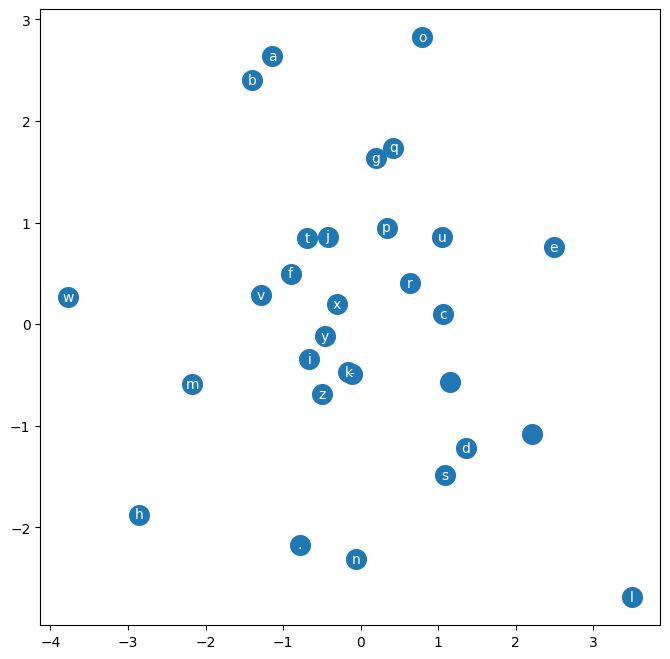

In [24]:
# 2d embedding table visualization
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8,8))
# Plot the dots (using .data to detach them from the autograd graph)
plt.scatter(C[:,0].data, C[:,1].data, s=200)

# Label the dots with the actual characters
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')

plt.grid('minor')
plt.show()

In [25]:
# sampling
for _ in range(20):
    out = []
    context = [0] * block_size # Start with [0, 0, 0]
    
    while True:
        X_sample = torch.tensor([context]) 
        
        emb = C[X_sample]
        xenc = emb.view(-1, emb.shape[1] * emb.shape[2])
        hidden = xenc @ W1 + b1
        h = torch.tanh(hidden)

        logits = h @ W2 + b2
        
        temperature = 0.8
        probs = F.softmax(logits / temperature, dim=1)

        # sample next character
        ix = torch.multinomial(probs, num_samples=1, replacement=True).item()

        #sliding context window
        context = context[1:] + [ix]

        if ix == 0:
            break

        # appending output word
        out.append(itos[ix])
            
    print("".join(out))

NameError: name 'block_size' is not defined